# Phase 1 — Data Pipeline Validation

Notebook này kiểm tra pipeline synthetic và noise bằng các hàm trong `src`; không cài đặt lại dataset/noise.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.datasets.regression import create_regression_dataset
from src.datasets.classification import create_classification_dataset
from src.noise.regression_noise import add_regression_noise
from src.noise.classification_noise import add_symmetric_label_noise

plt.style.use('seaborn-v0_8-whitegrid')
SEED, N_SAMPLES, N_FEATURES = 42, 5_000, 20
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = .70, .15, .15
REG_NOISE_LEVEL, CLS_NOISE_LEVEL, N_CLASSES = .20, .40, 3
print(f'Project root: {PROJECT_ROOT}')

Project root: D:\AIO\Topic_Team\code


## 1. Regression Dataset

Kiểm tra kích thước từng split, kiểu dữ liệu và chuẩn hóa feature trên **training set**.

In [2]:
reg_data = create_regression_dataset(
    n_samples=N_SAMPLES, n_features=N_FEATURES, n_informative=15, bias=0.0,
    train_size=TRAIN_SIZE, val_size=VAL_SIZE, test_size=TEST_SIZE, seed=SEED,
)
expected_rows = {'train': 3_500, 'val': 750, 'test': 750}
for split, expected_n in expected_rows.items():
    X, y = reg_data[f'X_{split}'], reg_data[f'y_{split}']
    assert X.shape == (expected_n, N_FEATURES) and y.shape == (expected_n,)
    assert X.dtype == np.float32 and y.dtype == np.float32
    assert np.isfinite(X).all() and np.isfinite(y).all()
    print(f'{split:>5}: X={X.shape}, y={y.shape}, dtype=({X.dtype}, {y.dtype})')

train_means = reg_data['X_train'].mean(axis=0)
train_stds = reg_data['X_train'].std(axis=0)
assert np.allclose(train_means, 0.0, atol=1e-6)
assert np.allclose(train_stds, 1.0, atol=1e-6)
print(f'max |train mean|: {np.abs(train_means).max():.2e}')
print(f'max |train std - 1|: {np.abs(train_stds - 1).max():.2e}')

train: X=(3500, 20), y=(3500,), dtype=(float32, float32)
  val: X=(750, 20), y=(750,), dtype=(float32, float32)
 test: X=(750, 20), y=(750,), dtype=(float32, float32)
max |train mean|: 2.98e-08
max |train std - 1|: 5.36e-07


## 2. Regression Noise Validation

Noise chỉ được thêm vào đúng số mẫu được chọn; target ngoài `noise_mask` phải giữ nguyên.

Noisy samples: 700/3500 (20.0%)
Added noise: mean=-2.370, std=209.045


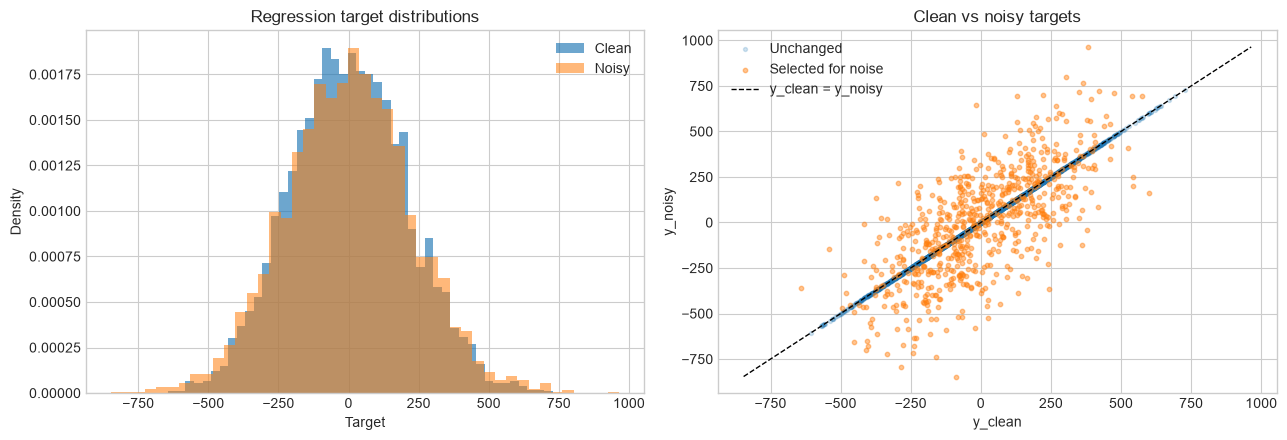

In [3]:
y_reg_clean = reg_data['y_train']
y_reg_noisy, reg_mask = add_regression_noise(
    y_reg_clean, noise_level=REG_NOISE_LEVEL, seed=SEED, noise_scale=1.0
)
expected_noisy = round(REG_NOISE_LEVEL * len(y_reg_clean))
assert y_reg_noisy.shape == y_reg_clean.shape and y_reg_noisy.dtype == np.float32
assert reg_mask.dtype == np.bool_ and int(reg_mask.sum()) == expected_noisy
assert np.array_equal(y_reg_noisy[~reg_mask], y_reg_clean[~reg_mask])
assert np.any(y_reg_noisy[reg_mask] != y_reg_clean[reg_mask])
added_noise = y_reg_noisy[reg_mask] - y_reg_clean[reg_mask]
print(f'Noisy samples: {reg_mask.sum()}/{len(reg_mask)} ({reg_mask.mean():.1%})')
print(f'Added noise: mean={added_noise.mean():.3f}, std={added_noise.std():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(y_reg_clean, bins=45, alpha=.65, label='Clean', density=True)
axes[0].hist(y_reg_noisy, bins=45, alpha=.55, label='Noisy', density=True)
axes[0].set(title='Regression target distributions', xlabel='Target', ylabel='Density')
axes[0].legend()
axes[1].scatter(y_reg_clean[~reg_mask], y_reg_noisy[~reg_mask], s=8, alpha=.2, label='Unchanged')
axes[1].scatter(y_reg_clean[reg_mask], y_reg_noisy[reg_mask], s=10, alpha=.45, label='Selected for noise')
limits = [min(y_reg_clean.min(), y_reg_noisy.min()), max(y_reg_clean.max(), y_reg_noisy.max())]
axes[1].plot(limits, limits, 'k--', linewidth=1, label='y_clean = y_noisy')
axes[1].set(title='Clean vs noisy targets', xlabel='y_clean', ylabel='y_noisy')
axes[1].legend()
plt.tight_layout(); plt.show()

## 3. Classification Dataset

Kiểm tra shape, dtype, miền nhãn và chuẩn hóa feature của dữ liệu classification.

In [4]:
cls_data = create_classification_dataset(
    n_samples=N_SAMPLES, n_features=N_FEATURES, n_informative=15,
    n_redundant=5, n_classes=N_CLASSES, class_sep=1.0,
    train_size=TRAIN_SIZE, val_size=VAL_SIZE, test_size=TEST_SIZE, seed=SEED,
)
for split, expected_n in expected_rows.items():
    X, y = cls_data[f'X_{split}'], cls_data[f'y_{split}']
    assert X.shape == (expected_n, N_FEATURES) and y.shape == (expected_n,)
    assert X.dtype == np.float32 and y.dtype == np.int64
    assert set(np.unique(y)) == set(range(N_CLASSES)) and np.isfinite(X).all()
    print(f'{split:>5}: X={X.shape}, y={y.shape}, classes={np.unique(y).tolist()}')

assert np.allclose(cls_data['X_train'].mean(axis=0), 0.0, atol=1e-6)
assert np.allclose(cls_data['X_train'].std(axis=0), 1.0, atol=1e-6)
print('Classification training features are standardized.')

train: X=(3500, 20), y=(3500,), classes=[0, 1, 2]
  val: X=(750, 20), y=(750,), classes=[0, 1, 2]
 test: X=(750, 20), y=(750,), classes=[0, 1, 2]
Classification training features are standardized.


## 4. Class Balance

Dataset gốc cân bằng và split có stratification, nên tỷ lệ mỗi lớp phải gần $1/3$.

train: counts=[1167, 1167, 1166], proportions=[0.3334, 0.3334, 0.3331]
  val: counts=[250, 250, 250], proportions=[0.3333, 0.3333, 0.3333]
 test: counts=[250, 250, 250], proportions=[0.3333, 0.3333, 0.3333]


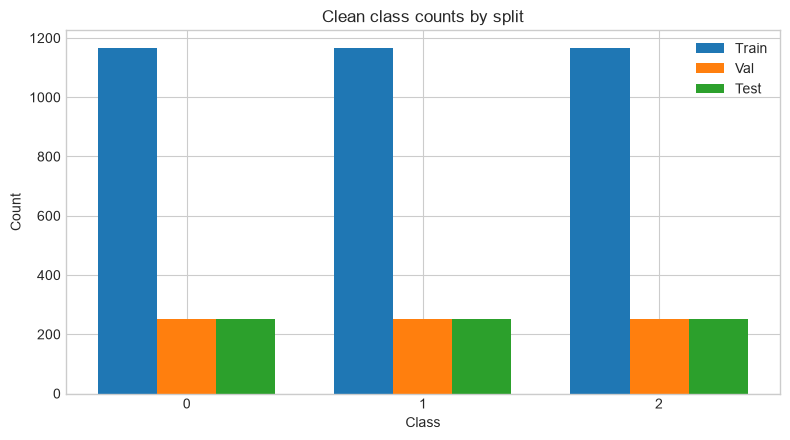

In [5]:
counts_by_split = {}
for split in ('train', 'val', 'test'):
    counts = np.bincount(cls_data[f'y_{split}'], minlength=N_CLASSES)
    proportions = counts / counts.sum()
    counts_by_split[split] = counts
    assert np.all(np.abs(proportions - 1 / N_CLASSES) < .02)
    print(f'{split:>5}: counts={counts.tolist()}, proportions={np.round(proportions, 4).tolist()}')

x, width = np.arange(N_CLASSES), .25
fig, ax = plt.subplots(figsize=(8, 4.5))
for offset, split in zip((-width, 0, width), ('train', 'val', 'test')):
    ax.bar(x + offset, counts_by_split[split], width, label=split.title())
ax.set(title='Clean class counts by split', xlabel='Class', ylabel='Count', xticks=x)
ax.legend(); plt.tight_layout(); plt.show()

## 5. Symmetric Label Noise Validation

Mẫu được chọn phải đổi sang **một lớp khác**; nhãn ngoài mask giữ nguyên và mọi nhãn noisy vẫn hợp lệ.

Flipped labels: 1400/3500 (40.0%)
Clean counts: [1167, 1167, 1166] | Noisy counts: [1193, 1180, 1127]


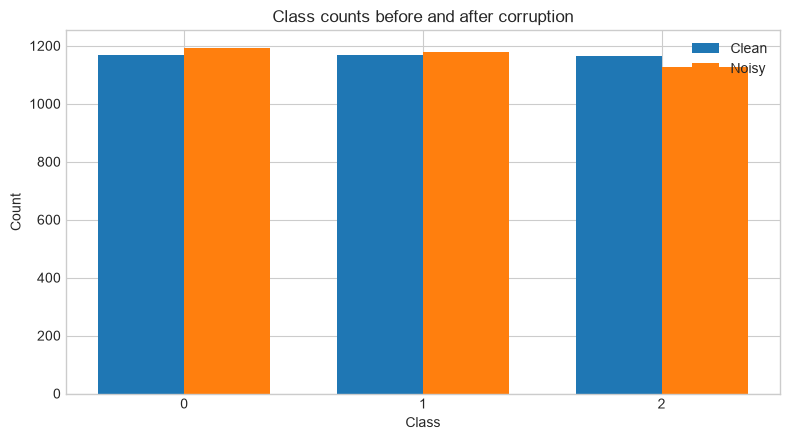

In [6]:
y_cls_clean = cls_data['y_train']
y_cls_noisy, cls_mask = add_symmetric_label_noise(
    y_cls_clean, noise_level=CLS_NOISE_LEVEL, n_classes=N_CLASSES, seed=SEED
)
expected_flips = round(CLS_NOISE_LEVEL * len(y_cls_clean))
assert y_cls_noisy.shape == y_cls_clean.shape and y_cls_noisy.dtype == np.int64
assert cls_mask.dtype == np.bool_ and int(cls_mask.sum()) == expected_flips
assert np.array_equal(y_cls_noisy[~cls_mask], y_cls_clean[~cls_mask])
assert np.all(y_cls_noisy[cls_mask] != y_cls_clean[cls_mask])
assert set(np.unique(y_cls_noisy)).issubset(set(range(N_CLASSES)))
clean_counts = np.bincount(y_cls_clean, minlength=N_CLASSES)
noisy_counts = np.bincount(y_cls_noisy, minlength=N_CLASSES)
print(f'Flipped labels: {cls_mask.sum()}/{len(cls_mask)} ({cls_mask.mean():.1%})')
print(f'Clean counts: {clean_counts.tolist()} | Noisy counts: {noisy_counts.tolist()}')

x, width = np.arange(N_CLASSES), .36
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, clean_counts, width, label='Clean')
ax.bar(x + width / 2, noisy_counts, width, label='Noisy')
ax.set(title='Class counts before and after corruption', xlabel='Class', ylabel='Count', xticks=x)
ax.legend(); plt.tight_layout(); plt.show()

## 6. Reproducibility Check

Cùng seed phải tạo lại đúng dataset, noisy target/label và mask; seed khác phải tạo kết quả khác.

In [7]:
reg_repeat = create_regression_dataset(seed=SEED)
cls_repeat = create_classification_dataset(seed=SEED)
assert all(np.array_equal(reg_data[key], reg_repeat[key]) for key in reg_data)
assert all(np.array_equal(cls_data[key], cls_repeat[key]) for key in cls_data)
reg_noisy_repeat, reg_mask_repeat = add_regression_noise(y_reg_clean, REG_NOISE_LEVEL, SEED, 1.0)
cls_noisy_repeat, cls_mask_repeat = add_symmetric_label_noise(y_cls_clean, CLS_NOISE_LEVEL, N_CLASSES, SEED)
assert np.array_equal(y_reg_noisy, reg_noisy_repeat) and np.array_equal(reg_mask, reg_mask_repeat)
assert np.array_equal(y_cls_noisy, cls_noisy_repeat) and np.array_equal(cls_mask, cls_mask_repeat)
assert not np.array_equal(reg_data['X_train'], create_regression_dataset(seed=SEED + 1)['X_train'])
assert not np.array_equal(cls_data['X_train'], create_classification_dataset(seed=SEED + 1)['X_train'])
print('PASS: reproducible với cùng seed; seed khác tạo datasets khác.')

PASS: reproducible với cùng seed; seed khác tạo datasets khác.


## 7. Phase 1 Conclusions

Nếu không có `AssertionError`: dataset có đúng split/shape/dtype; feature training được chuẩn hóa; class cân bằng; hai loại noise tác động đúng số mẫu và đúng semantics của mask; pipeline tái lập với cùng seed.

**Kết luận:** data pipeline sẵn sàng cho training/evaluation.